# 02 - Tiền xử lý dữ liệu (Preprocessing)

Mục tiêu: Làm sạch, chuẩn hóa, và lưu dữ liệu đã xử lý cho EDA và Visualization.

## 1. Pipeline
- Hợp nhất dữ liệu từ nhiều nguồn
- Làm sạch giá/đánh giá/số lượng bán
- Chuẩn hóa định dạng thời gian
- Lưu dữ liệu vào data/processed

## 2. Import Libraries

In [1447]:
# import libraries
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re


## 3. Load and Explore Dataset

**Giải thích:** Tải dữ liệu và khám phá cấu trúc ban đầu.

In [1448]:
current_path = os.getcwd()
parent_path = os.path.dirname(current_path)

data_file_name = 'raw_final.csv'
data_path = os.path.join(parent_path, 'data', data_file_name)
data_path

'd:\\Đại học\\Kỳ 8\\Class - Data visualization\\Lab\\Lab 1\\Lab1---Data-Visualization-\\data\\raw_final.csv'

In [1449]:
# Read data and general obverse
df = pd.read_csv(data_path)
df.head()


,ID,Giá (tỷ đồng),Giá đã tăng 1 năm qua (%),Diện tích,Số phòng tắm,Số phòng ngủ,Số tầng,Có nội thất,Mặt tiền(m),Đường vào(m),...,Loại Tin,ngày crawl,blocked,source_url,address,legal,raw_price,raw_area,page_title,_source_file
0,45013660.0,7.80,11.7,68.0,6.0,6.0,5.0,1,4.0,6.0,...,Tin thường,2026-02-22 09:05:00.013029,False,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Nguyễn Duy Cung, Phường 12, Quận Gò Vấp,...",Sổ đỏ/ Sổ hồng,"7,8 tỷ",68 m²,"Hàng Hiếm DT 68m2 x5 tầng hẻm 6m, chỉ 7.8 tỷ p...",scraped_results_p273.csv
1,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,Tin thường,2026-02-22 09:05:02.875637,False,https://batdongsan.com.vn/ban-dat-duong-pham-v...,"Đường Phạm Văn Chiêu, Phường 14, Quận Gò Vấp, ...",Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...,scraped_results_p273.csv
2,45013679.0,11.00,5.2,62.0,8.0,8.0,4.0,1,4.0,13.0,...,Tin thường,2026-02-22 09:06:12.711070,False,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,"Đường Lê Quốc Trinh, Phường Phú Thọ Hòa, Quận ...",Sổ đỏ/ Sổ hồng,11 tỷ,62 m²,"HÀNG KÍN , NHÀ MẶT PHỐ 62m2 DÒNG TIỀN 40Tr/th ...",scraped_results_p273.csv
3,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,Tin thường,2026-02-22 13:13:19.065024,False,https://batdongsan.com.vn/ban-dat-duong-pham-v...,"Đường Phạm Văn Chiêu, Phường 14, Quận Gò Vấp, ...",Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...,scraped_results_p371.csv
4,45106540.0,9.50,11.1,62.7,4.0,3.0,4.0,1,5.0,NaN,...,Tin thường,2026-02-22 13:13:21.677059,False,https://batdongsan.com.vn/ban-nha-rieng-phuong...,"Phường Phú Thuận, Quận 7, Hồ Chí Minh",Sổ đỏ/ Sổ hồng,"9,5 tỷ","62,7 m²","Bán nhà quận 7, nhà mới khu cao tầng Lacasa Ho...",scraped_results_p371.csv


Nhận xét: Tên cột chưa thống nhất về ngôn ngữ

Đổi tên cột thành english cho đồng nhất và dễ truy xuất

In [1450]:
column_mapping = {
    'Giá (tỷ đồng)': 'price',
    'Giá đã tăng 1 năm qua (%)': 'price_increased',
    'Diện tích': 'area',
    'Số phòng tắm': 'num_bathrooms',
    'Số phòng ngủ': 'num_bedrooms',
    'Số tầng': 'num_floors',
    'Có nội thất': 'has_furniture',
    'Mặt tiền(m)': 'frontage',
    'Đường vào(m)': 'entrance',
    'Hướng nhà': 'house_direction',
    'Đường': 'street',
    'Phường': 'ward',
    'Quận': 'district',
    'Thành Phố': 'city',
    'Vĩ độ': 'latitude',
    'Kinh độ': 'longitude',
    'Có sổ hồng': 'has_pink_book',
    'Có xác thực': 'is_verified',
    'Ngày đăng': 'posted_date',
    'Ngày hết hạn': 'expired_date',
    'Loại Tin': 'post_type',
    'ngày crawl': 'crawled_date'
}

df = df.rename(columns=column_mapping)
df.columns

Index(['ID', 'price', 'price_increased', 'area', 'num_bathrooms',
       'num_bedrooms', 'num_floors', 'has_furniture', 'frontage', 'entrance',
       'house_direction', 'street', 'ward', 'district', 'city', 'latitude',
       'longitude', 'has_pink_book', 'is_verified', 'posted_date',
       'expired_date', 'post_type', 'crawled_date', 'blocked', 'source_url',
       'address', 'legal', 'raw_price', 'raw_area', 'page_title',
       '_source_file'],
      dtype='object')

In [1451]:
df.head()

,ID,price,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,...,post_type,crawled_date,blocked,source_url,address,legal,raw_price,raw_area,page_title,_source_file
0,45013660.0,7.80,11.7,68.0,6.0,6.0,5.0,1,4.0,6.0,...,Tin thường,2026-02-22 09:05:00.013029,False,https://batdongsan.com.vn/ban-nha-rieng-duong-...,"Đường Nguyễn Duy Cung, Phường 12, Quận Gò Vấp,...",Sổ đỏ/ Sổ hồng,"7,8 tỷ",68 m²,"Hàng Hiếm DT 68m2 x5 tầng hẻm 6m, chỉ 7.8 tỷ p...",scraped_results_p273.csv
1,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,Tin thường,2026-02-22 09:05:02.875637,False,https://batdongsan.com.vn/ban-dat-duong-pham-v...,"Đường Phạm Văn Chiêu, Phường 14, Quận Gò Vấp, ...",Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...,scraped_results_p273.csv
2,45013679.0,11.00,5.2,62.0,8.0,8.0,4.0,1,4.0,13.0,...,Tin thường,2026-02-22 09:06:12.711070,False,https://batdongsan.com.vn/ban-nha-mat-pho-duon...,"Đường Lê Quốc Trinh, Phường Phú Thọ Hòa, Quận ...",Sổ đỏ/ Sổ hồng,11 tỷ,62 m²,"HÀNG KÍN , NHÀ MẶT PHỐ 62m2 DÒNG TIỀN 40Tr/th ...",scraped_results_p273.csv
3,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,Tin thường,2026-02-22 13:13:19.065024,False,https://batdongsan.com.vn/ban-dat-duong-pham-v...,"Đường Phạm Văn Chiêu, Phường 14, Quận Gò Vấp, ...",Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...,scraped_results_p371.csv
4,45106540.0,9.50,11.1,62.7,4.0,3.0,4.0,1,5.0,NaN,...,Tin thường,2026-02-22 13:13:21.677059,False,https://batdongsan.com.vn/ban-nha-rieng-phuong...,"Phường Phú Thuận, Quận 7, Hồ Chí Minh",Sổ đỏ/ Sổ hồng,"9,5 tỷ","62,7 m²","Bán nhà quận 7, nhà mới khu cao tầng Lacasa Ho...",scraped_results_p371.csv


### 3.1 Thông tin cơ bản

In [1452]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26003 entries, 0 to 26002
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               25992 non-null  float64
 1   price            25589 non-null  float64
 2   price_increased  25338 non-null  float64
 3   area             25992 non-null  float64
 4   num_bathrooms    16581 non-null  float64
 5   num_bedrooms     17255 non-null  float64
 6   num_floors       13855 non-null  float64
 7   has_furniture    26003 non-null  int64  
 8   frontage         14759 non-null  float64
 9   entrance         13784 non-null  float64
 10  house_direction  6374 non-null   object 
 11  street           24881 non-null  object 
 12  ward             25609 non-null  object 
 13  district         25992 non-null  object 
 14  city             25988 non-null  object 
 15  latitude         26003 non-null  float64
 16  longitude        26003 non-null  float64
 17  has_pink_boo

In [1453]:
df.describe()

,ID,price,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,latitude,longitude,has_pink_book,is_verified
count,2.599200e+04,25589.000000,25338.000000,25992.000000,16581.000000,17255.000000,13855.000000,26003.000000,14759.000000,13784.000000,26003.000000,26003.000000,26003.000000,26003.000000
mean,4.434029e+07,15.502130,15.437900,107.808228,3.702551,3.795653,3.396175,0.476522,7.106894,9.697816,10.838205,106.686777,0.835365,0.395916
std,1.906969e+06,32.573744,16.493202,101.143715,2.937559,3.311654,1.433034,0.499458,6.337704,7.729282,0.678989,0.088551,0.370858,0.489056
min,1.025049e+07,0.003300,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.700000,2.000000,10.377331,105.784046,0.000000,0.000000
25%,4.438190e+07,4.850000,6.100000,58.000000,2.000000,2.000000,2.000000,0.000000,4.000000,5.000000,10.755193,106.639742,1.000000,0.000000
50%,4.494123e+07,7.700000,11.800000,79.000000,3.000000,3.000000,3.000000,0.000000,5.000000,8.000000,10.793281,106.689895,1.000000,0.000000
75%,4.511144e+07,12.900000,19.700000,114.600000,5.000000,4.000000,4.000000,1.000000,8.000000,12.000000,10.838277,106.732466,1.000000,1.000000
max,4.516404e+07,985.000000,272.700000,997.000000,75.000000,128.000000,22.000000,1.000000,200.000000,200.000000,21.029380,107.101275,1.000000,1.000000


In [1454]:
df.isnull().sum()

ID                    11
price                414
price_increased      665
area                  11
num_bathrooms       9422
num_bedrooms        8748
num_floors         12148
has_furniture          0
frontage           11244
entrance           12219
house_direction    19629
street              1122
ward                 394
district              11
city                  15
latitude               0
longitude              0
has_pink_book          0
is_verified            0
posted_date           11
expired_date          11
post_type             11
crawled_date           0
blocked                0
source_url             0
address               11
legal               2530
raw_price             11
raw_area              11
page_title             0
_source_file           0
dtype: int64

In [1455]:
df.columns

Index(['ID', 'price', 'price_increased', 'area', 'num_bathrooms',
       'num_bedrooms', 'num_floors', 'has_furniture', 'frontage', 'entrance',
       'house_direction', 'street', 'ward', 'district', 'city', 'latitude',
       'longitude', 'has_pink_book', 'is_verified', 'posted_date',
       'expired_date', 'post_type', 'crawled_date', 'blocked', 'source_url',
       'address', 'legal', 'raw_price', 'raw_area', 'page_title',
       '_source_file'],
      dtype='object')

In [1456]:
df['blocked'].unique()

array([False])

Nhận xét: 

* Cột dư: _source_file, blocked và crawled_date, source_url, page_title
* raw_area và area khác gì nhau?
* price và raw_price khác gì nhau?
* address và các cột ward, district, city dư -> loại cột address
* Trong dữ liệu có cột legal có cột sổ đỏ, sổ hồng và còn các giấy phép khác, has_pink_book là có sổ đỏ hay không -> xem xét phần giấy phép để coi có nên giữ hay không


In [1457]:
df.drop(columns=['address', 'blocked', 'crawled_date', 'source_url', '_source_file'], inplace=True)
df.head(5)

,ID,price,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,...,longitude,has_pink_book,is_verified,posted_date,expired_date,post_type,legal,raw_price,raw_area,page_title
0,45013660.0,7.80,11.7,68.0,6.0,6.0,5.0,1,4.0,6.0,...,106.641924,1,0,2026-02-14,2026-03-01,Tin thường,Sổ đỏ/ Sổ hồng,"7,8 tỷ",68 m²,"Hàng Hiếm DT 68m2 x5 tầng hẻm 6m, chỉ 7.8 tỷ p..."
1,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,106.648048,1,1,2026-02-20,2026-03-07,Tin thường,Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...
2,45013679.0,11.00,5.2,62.0,8.0,8.0,4.0,1,4.0,13.0,...,106.623475,1,0,2026-02-10,2026-02-25,Tin thường,Sổ đỏ/ Sổ hồng,11 tỷ,62 m²,"HÀNG KÍN , NHÀ MẶT PHỐ 62m2 DÒNG TIỀN 40Tr/th ..."
3,45056216.0,9.99,0.0,80.0,NaN,NaN,NaN,0,4.0,NaN,...,106.648048,1,1,2026-02-20,2026-03-07,Tin thường,Sổ đỏ/ Sổ hồng,"9,99 tỷ",80 m²,Đất hiếm 80m2 mặt tiền Phạm Văn Chiêu khúc kin...
4,45106540.0,9.50,11.1,62.7,4.0,3.0,4.0,1,5.0,NaN,...,106.744594,1,1,2026-02-12,2026-02-27,Tin thường,Sổ đỏ/ Sổ hồng,"9,5 tỷ","62,7 m²","Bán nhà quận 7, nhà mới khu cao tầng Lacasa Ho..."


In [1458]:
df.columns

Index(['ID', 'price', 'price_increased', 'area', 'num_bathrooms',
       'num_bedrooms', 'num_floors', 'has_furniture', 'frontage', 'entrance',
       'house_direction', 'street', 'ward', 'district', 'city', 'latitude',
       'longitude', 'has_pink_book', 'is_verified', 'posted_date',
       'expired_date', 'post_type', 'legal', 'raw_price', 'raw_area',
       'page_title'],
      dtype='object')

### 3.2 EDA và Clean data

#### 3.2.1 Duplication

Đếm số row lặp

In [1459]:
print(df.shape)
print(df.duplicated().sum())

(26003, 26)
12148


In [1460]:
print('Số ID duy nhất:', df['ID'].unique().shape[0])
print('Số dòng có ID null: ', df[df['ID'].isnull()].shape[0])

Số ID duy nhất: 13738
Số dòng có ID null:  11


**Nhận xét**: 
* Quan sát: Có nhiều dòng trùng rất nhiều dòng trùng (12160) -> có thể do dòng trùng là NaN ở nhiều cột
* Xử lý: Xóa các dòng trùng

In [1461]:
df.drop_duplicates(inplace=True)
print('Số dòng sau khi loại bỏ trùng lặp:', df.shape[0])

Số dòng sau khi loại bỏ trùng lặp: 13855


In [1462]:
# Kiểm tra ID trùng
duplicate_ids = df[df.duplicated(subset=['ID'], keep=False)]['ID']
print('Số ID trùng:', duplicate_ids.nunique())

Số ID trùng: 116


In [1463]:
dup_id_df = df[df['ID'].isin(duplicate_ids)].sort_values(by='ID')
dup_id_df

,ID,price,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,...,longitude,has_pink_book,is_verified,posted_date,expired_date,post_type,legal,raw_price,raw_area,page_title
2368,37219647.0,10.3,11.6,100.0,NaN,NaN,3.0,1,NaN,NaN,...,106.664400,0,0,2026-02-17,2026-03-04,Tin thường,NaN,"10,3 tỷ",100 m²,Bán nhà phố đảo thiên đường - Khu đô thị Mizuk...
16258,37219647.0,10.3,11.6,100.0,NaN,NaN,3.0,1,NaN,NaN,...,106.664400,0,0,2026-01-31,2026-02-15,Tin thường,NaN,"10,3 tỷ",100 m²,Bán nhà phố đảo thiên đường - Khu đô thị Mizuk...
17250,39396373.0,17.0,3.3,95.0,5.0,5.0,4.0,0,5.0,16.0,...,106.792092,1,0,2026-02-01,2026-02-16,Tin thường,Sổ đỏ/ Sổ hồng,17 tỷ,95 m²,"Bán cắt lỗ 2 căn dãy hồ bơi . DT 5x18m, 5x19m ..."
3757,39396373.0,16.5,3.3,95.0,5.0,5.0,4.0,0,5.0,16.0,...,106.792092,1,0,2026-02-16,2026-03-03,Tin thường,Sổ đỏ/ Sổ hồng,"16,5 tỷ",95 m²,"Bán cắt lỗ 2 căn dãy hồ bơi . DT 5x18m, 5x19m ..."
1066,40937188.0,7.2,12.2,150.0,5.0,5.0,3.0,1,5.0,8.0,...,106.571476,1,0,2026-02-18,2026-03-05,Tin thường,Sổ đỏ/ Sổ hồng,"7,2 tỷ",150 m²,"Nhà phố xinh, DT 5m x 30m (5PN) mặt tiền kinh ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7122,45160361.0,5.3,41.1,124.0,2.0,3.0,NaN,0,NaN,NaN,...,106.727700,1,0,2026-02-13,2026-02-28,Tin thường,Sổ đỏ/ Sổ hồng,"5,3 tỷ",124 m²,"Căn hộ CC 3PN. Giá: 5,3 tỷ, 124m2 tại Belleza ..."
7089,45160375.0,52.0,11.9,200.0,75.0,75.0,8.0,1,NaN,NaN,...,106.659669,1,0,2026-02-13,2026-02-28,Tin thường,Sổ đỏ/ Sổ hồng,52 tỷ,200 m²,"Quang Trung 8 tầng, 75 phòng (DT 3.4tỷ/năm), 2..."
12858,45160375.0,52.0,11.9,200.0,75.0,75.0,8.0,1,NaN,NaN,...,106.659669,1,0,2026-02-13,2026-02-28,Tin thường,Sổ đỏ/ Sổ hồng,52 tỷ,200 m²,"Quang Trung 8 Tầng, 75 Phòng (DT 3.4ty/năm), 2..."
439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,...,105.852447,0,0,NaN,NaN,NaN,NaN,NaN,NaN,"Nền tảng bất động sản uy tín - Mua bán, cho th..."


Thường thì những attributes nào sẽ bị thay đổi? Những attributes đó bị thay đổi do lý do gì?

In [1464]:
# số lượng giá trị khác nhau trong mỗi cột cho mỗi ID trùng
diff_cols = dup_id_df.groupby('ID').nunique()
(diff_cols > 1).sum()

price               4
price_increased     2
area                4
num_bathrooms       1
num_bedrooms        1
num_floors          0
has_furniture       1
frontage            1
entrance            1
house_direction     0
street             29
ward                6
district           41
city                0
latitude            9
longitude           9
has_pink_book       1
is_verified         1
posted_date        84
expired_date       84
post_type          14
legal               0
raw_price           5
raw_area            4
page_title         29
dtype: int64

**Nhận xét:**
* Quan sát: Có những dòng trùng ID và khác một số attributes
* Lý do: 
    * TH1: Theo góc nhìn website thì có thể do người bán cập nhật thông tin -> crawl dữ liệu tại 2 thời điểm khác nhau nên bị trùng ID tại thời điểm cập nhật giá, thông tin bán.
    * TH2: Có thể do người đăng quên xóa bài cũ và đăng luôn bài mới -> đăng lại
    * TH3: Có thể do join/merge sai
* Xử lý:
    * Ưu tiên lấy dòng ở bài đăng sau (vì không phân tích giá biến động)
    * Những dòng còn lại thì lấy theo last version -> chấp nhận sai sót (vì không đủ cơ sở)

In [1465]:
duplicated_df = (
    df.sort_values('posted_date')
      .drop_duplicates(subset='ID', keep='last')
)
duplicate_ids = duplicated_df[duplicated_df.duplicated(subset=['ID'], keep=False)]['ID']
dup_id_df = duplicated_df[duplicated_df['ID'].isin(duplicate_ids)].sort_values(by='ID')
dup_id_df

,ID,price,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,...,longitude,has_pink_book,is_verified,posted_date,expired_date,post_type,legal,raw_price,raw_area,page_title


In [1466]:
print(duplicated_df.shape)
duplicated_df.to_csv(os.path.join(parent_path, 'data', 'processed','1_duplicated_data.csv'), index=False)

(13738, 26)


#### 3.2.2 Missing values


**Lý thuyết**

1. **MCAR (Missing Completely At Random):** 
* Định nghĩa: Lỗi thiếu dữ liệu hoàn toàn ngẫu nhiên hay xác suất một giá trị bị thiếu không phụ thuộc vào bất kỳ biến nào, kể cả chính nó.
$$ P(Missing∣X,Y) = P(Missing) $$
* Xảy ra khi:
    * Có yếu tố ngoại sinh, kỹ thuật, ngẫu nhiên:
        * Lỗi thiết bị đo làm mất bản ghi ngẫu nhiên.
        * Lỗi nhập liệu, mất file tạm thời.
        * Một số bảng hỏi bị thất lạc ngẫu nhiên trong quá trình thu thập.
        * Hệ thống IT ghi log bị gián đoạn trong vài phút.
        * Ví dụ: Trong khảo sát 1.000 người, 5% bảng hỏi bị thất lạc do lỗi in ấn – không liên quan đến tuổi, giới tính, thu nhập… → có thể xem là MCAR.
    * Dấu hiệu và cách thức nhận biết MCAR:
        * So sánh nhóm có thiếu vs không thiếu:
            * Chia dữ liệu thành 2 nhóm: có missing và không missing.
            * So sánh trung bình/tỷ lệ các biến quan sát được.
            * Nếu không có khác biệt có ý nghĩa thống kê, MCAR có khả năng đúng.
        * Kiểm định Little’s MCAR test
            * Kiểm định giả thuyết:
                * H0: Dữ liệu là MCAR
                * Nếu p-value > 0.05 → không bác bỏ H0 → có thể là MCAR
        * Phân tích mô hình logistic
            * Dùng biến nhị phân (1 = thiếu, 0 = không thiếu) làm biến phụ thuộc.       
* Phương pháp xử lý MCAR:
    * Listwise Deletion (Complete Case Analysis): Loại bỏ toàn bộ dòng có missing.
    * Pairwise Deletion: Dùng tối đa dữ liệu sẵn có cho từng phân tích. 
    * Mean/Median Imputation: Thay bằng trung bình/trung vị.
    * Multiple Imputation: Tạo nhiều bộ dữ liệu thay thế.
    * Maximum Likelihood: Ước lượng trực tiếp từ dữ liệu chưa hoàn chỉnh.

2. **MAR (Missing At Random):** 
* MAR là cơ chế thiếu dữ liệu khi xác suất bị thiếu phụ thuộc vào các biến quan sát được, nhưng không phụ thuộc vào chính giá trị bị thiếu, sau khi đã kiểm soát các biến quan sát đó.
* MAR xảy ra khi:
    $$P(R∣Y_{obs​},Y_{mis​})=P(R∣Y{obs​})$$
    Trong đó: 
    * $Y_{obs​}$: dữ liệu quan sát được
    * $Y_{mis}$: dữ liệu thiếu
    * $R$: biến chỉ báo thiếu dữ liệu
* Ví dụ MAR: Một khảo sát thu nhập.
    * Nam giới ít trả lời câu hỏi về thu nhập hơn nữ.
    * Nhưng trong mỗi nhóm giới tính, việc có trả lời hay không không phụ thuộc vào mức thu nhập thực tế.
    → Xác suất thiếu phụ thuộc vào giới tính (biến quan sát được), không phụ thuộc vào thu nhập thật sự
* Dấu hiệu phát hiện MAR: 
    * So sánh nhóm có missing vs không missing: Nếu thấy sự khác biệt theo biến quan sát được (tuổi, giới, thu nhập…) → Có khả năng MAR.
    * Little’s MCAR test
    * Logistic regression dự đoán missing
* Phương pháp xử lý MAR:
    * Multiple Imputation
        * Tạo nhiều bộ dữ liệu thay thế.
        * Dựa trên các biến quan sát được để dự đoán giá trị thiếu.
        * Kết quả được gộp lại (Rubin’s Rules).
        * Hoạt động tốt khi MAR đúng.
    * KNN imputation
    * Model-based approaches: regression imputation.
    * Maximum Likelihood (FIML): Ước lượng trực tiếp từ dữ liệu không hoàn chỉnh. (SEM, CFA)
    * Không nên dùng Mean imputation hay Listwise deletion (khi tỷ lệ missing đáng kể)

3. **MNAR (Missing Not At Random):**
* MNAR (Missing Not At Random) là cơ chế thiếu dữ liệu khi: Xác suất một giá trị bị thiếu phụ thuộc vào chính giá trị bị thiếu đó, ngay cả khi đã kiểm soát các biến quan sát được.
* Dữ liệu bị thiếu không phải ngẫu nhiên, và lý do thiếu liên quan đến bản thân giá trị thật sự của biến đó.
* MNAR xảy ra khi:
    * Khi giá trị “nhạy cảm”, liên quan đến cá nhân hóa, có cơ chế tự chọn (self-selection bias)
        * Giá trị càng cao hoặc càng thấp thì xác suất thiếu càng lớn -> bias (thu nhập, cân nặng, ...)
    * Khi kết quả xấu làm người tham gia rút lui
* Dấu hiệu phát hiện MNAR:
    * Mô hình MAR không giải thích được missingness
        * Logistic regression dự đoán missing ~ các biến quan sát
        * Nếu R² rất thấp → có thể missing phụ thuộc vào chính biến đó
    * Phân phối biến bị thiếu lệch rõ rệt: So sánh nhóm có dữ liệu và nhóm thiếu, nếu phân phối khác biệt lớn → nghi ngờ MNAR
    * Có lý do lý thuyết/logic thực tế (kiến thức chuyên môn quan trọng hơn test thống kê)
* Lưu ý: MNAR nguy hiểm vì
    * Ước lượng bị bias nghiêm trọng
    * Imputation chuẩn (Mean/MI/MAR-based) sẽ sai
    * Kết luận nghiên cứu có thể lệch hệ thống
* Phương pháp xử lý MNAR: không có cơ chế xử lý cố định, hoàn hảo
    * Sensitivity Analysis: Thử nhiều giả định khác nhau về giá trị bị thiếu
    * Selection Model
    * Pattern-Mixture Model: Chia dữ liệu theo pattern missing (complete, missing)
    * Heckman Selection Model: Dùng khi có bias do self-selection (kinh tế lượng)
        1. Phương trình chọn mẫu
        2. Phương trình kết quả
        3. Hiệu chỉnh bằng Inverse Mills Ratio
    * Bayesian Modeling:
        * Đặt prior cho phân phối giá trị bị thiếu
        * Mô hình joint distribution

##### **3.2.2.1 Visualization + analysis**

a. Số lượng missing values theo cột

In [1467]:
# Missing value
df = pd.read_csv(os.path.join(parent_path, 'data', 'processed','1_duplicated_data.csv'))
df.isnull().sum()

ID                     1
price                322
price_increased      424
area                   1
num_bathrooms       4824
num_bedrooms        4268
num_floors          6478
has_furniture          0
frontage            6558
entrance            7210
house_direction    10391
street               428
ward                 117
district               1
city                   5
latitude               0
longitude              0
has_pink_book          0
is_verified            0
posted_date            1
expired_date           1
post_type              1
legal               2012
raw_price              1
raw_area               1
page_title             0
dtype: int64

b. Visualize những cột có missing values

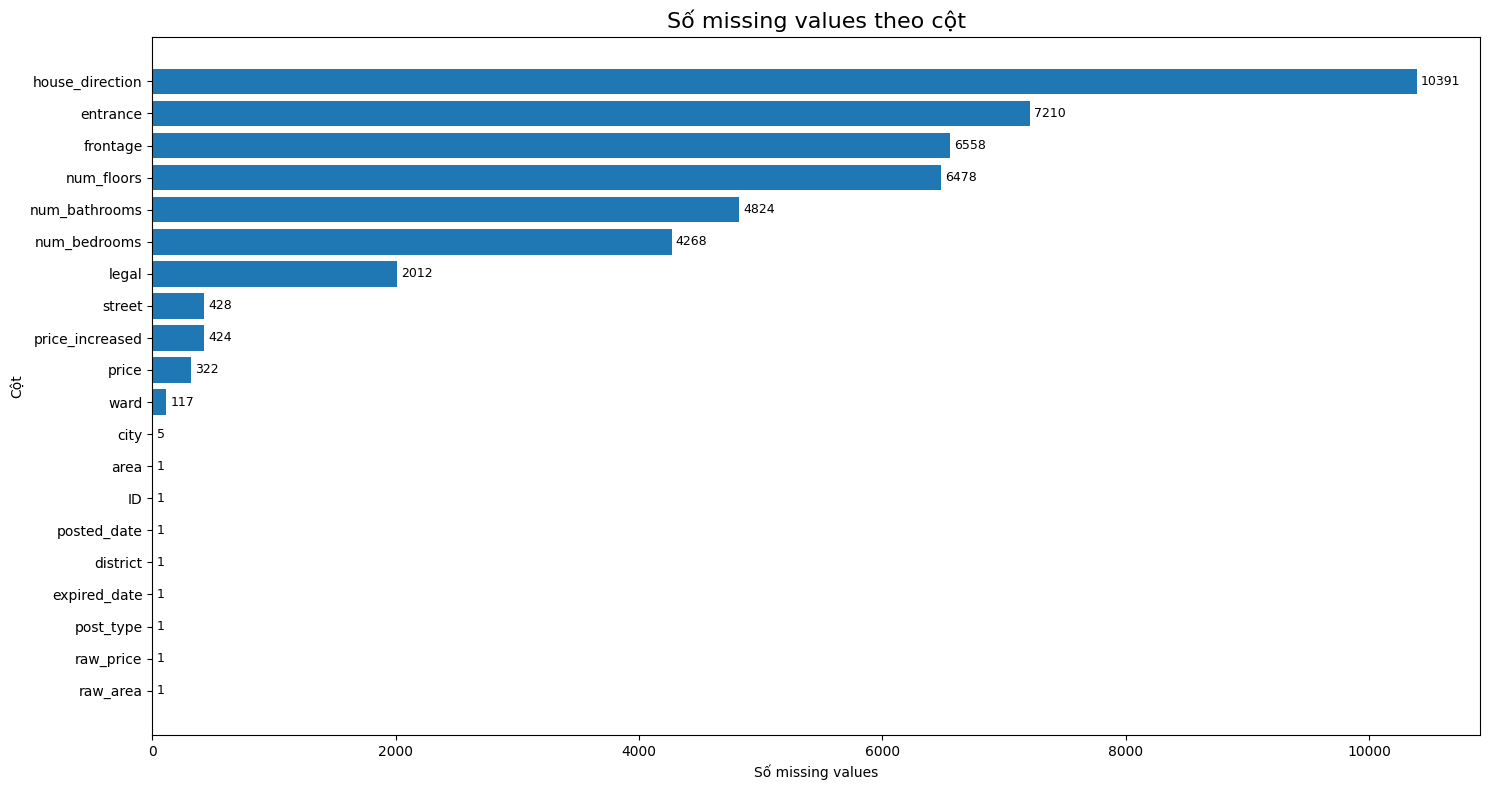

In [1468]:
# Bar chart dạng ngang (horizontal) của missing values + hiển thị con số
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

def visualize_missing_values(missing_values):
    fig_height = max(4, 0.4 * len(missing_values))
    fig, ax = plt.subplots(figsize=(15, fig_height))
    bars = ax.barh(
        missing_values.index.astype(str),
        missing_values.values,
    )

    ax.set_title("Số missing values theo cột", fontsize=16)
    ax.set_xlabel("Số missing values")
    ax.set_ylabel("Cột")
    ax.invert_yaxis()

    # Ghi con số ở cuối mỗi thanh
    for bar in bars:
        width = bar.get_width()
        ax.annotate(
            f"{int(width)}",
            xy=(width, bar.get_y() + bar.get_height() / 2),
            xytext=(3, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()

visualize_missing_values(missing_values)

c. Missing heatmap

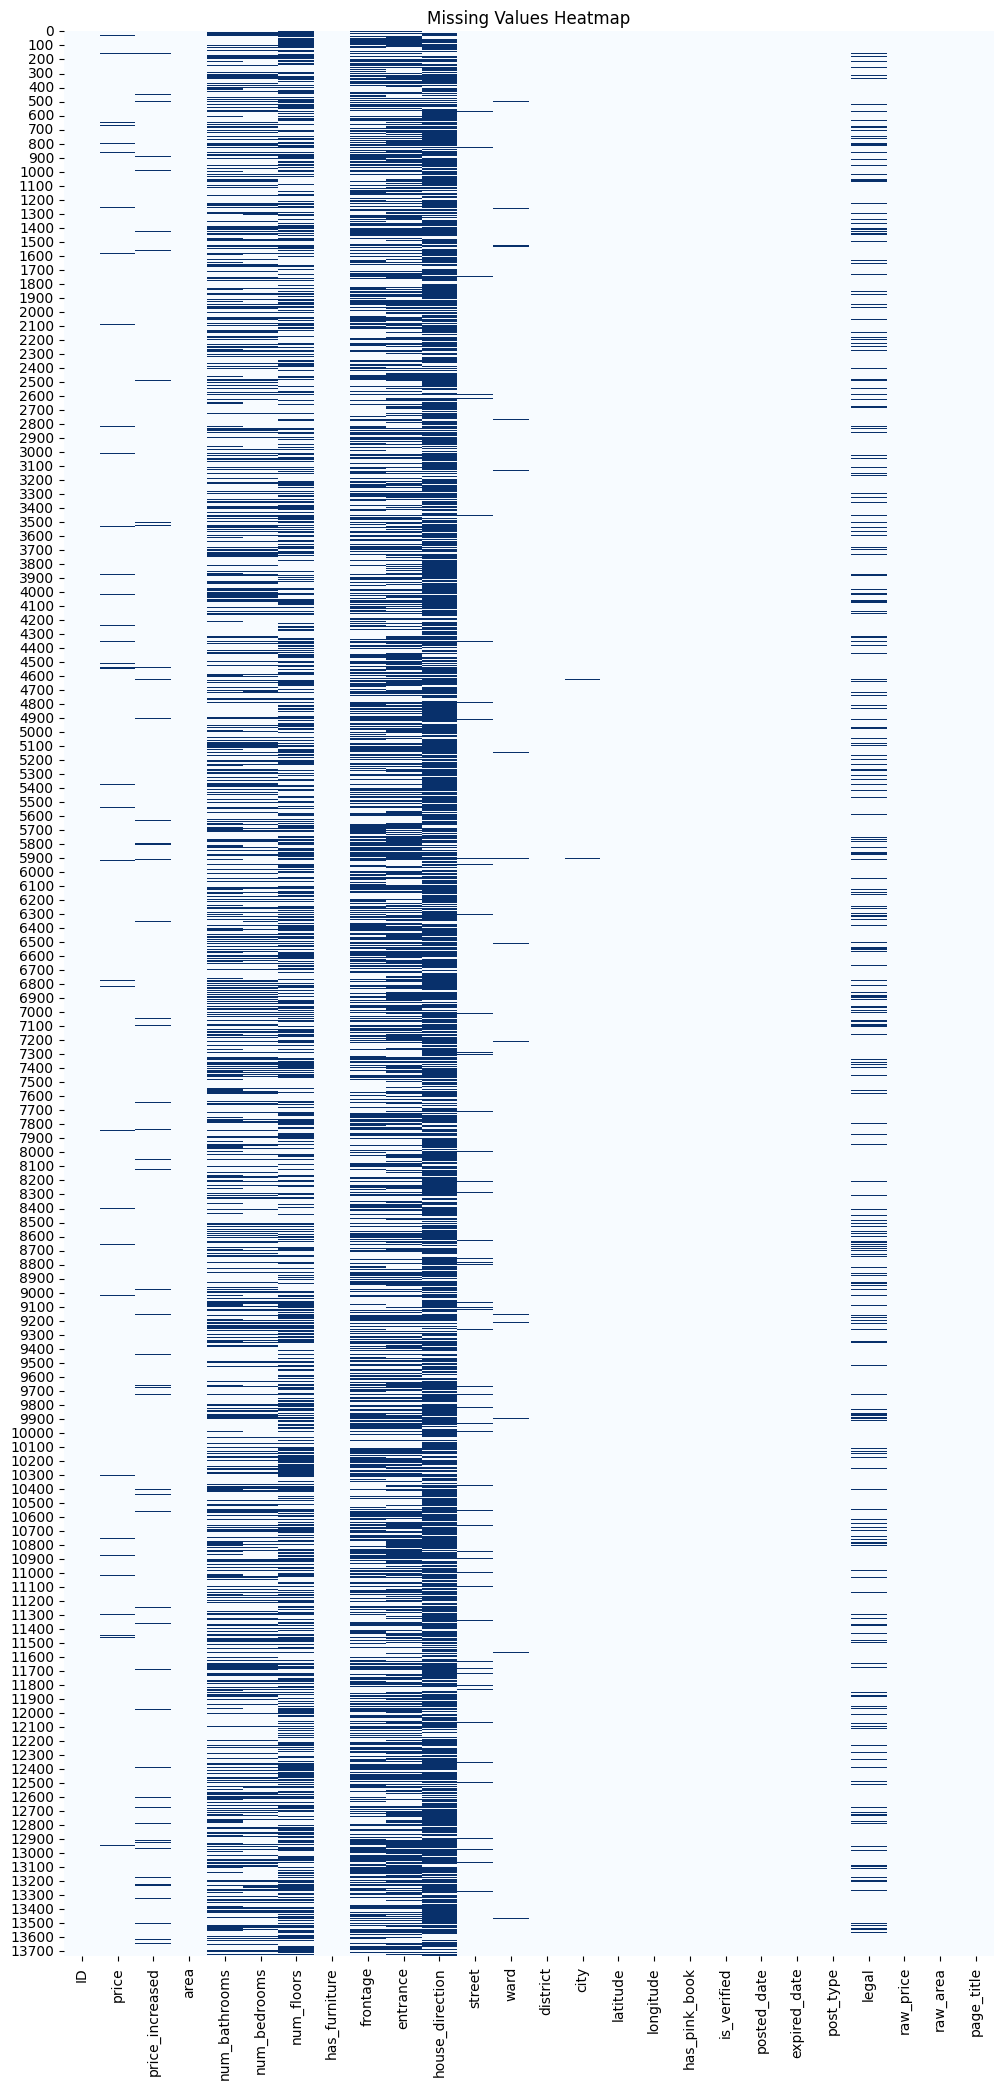

In [1469]:
plt.figure(figsize=(12, 25))
sns.heatmap(df.isna(), cbar=False, cmap='Blues')
plt.title('Missing Values Heatmap')
plt.show()

**Nhận xét**:
1. **Nhóm thiếu dữ liệu đầy đủ hoặc thiếu dữ liệu rải rác**: ID, area, has_furniture, district, city (có một vạch nhỏ ở dưới), latitude, longitude, has_pink_book, is_verified, posted_date, expired_date, post_type, raw_price, raw_area -> dữ liệu có tác dụng trong phân tích, nhóm thiếu rải rác thì không ảnh hưởng (Có thể dùng imputation hoặc các phương pháp thống kê để xử lý)

2. **Nhóm thiếu dữ liệu trung bình - cao**: price, price_increased, street, ward, legal
    * price_increased và price: Có thể xử lý bằng raw_price
    * street, ward: có thể cân nhắc nhập "Không rõ"
    * legal: có liên quan đến cột has_pink_book nên có thể bỏ qua hoặc nếu nghiên cứu sâu hơn để chia ra các dạng mức độ của giấy tờ thì đặt 'Không rõ' để xử lý (vì cũng mang thông tin).
3. **Nhóm thiếu dữ liệu nghiêm trọng và dày đặc**: house_direction, entrance, frontage, num_floors -> dữ liệu có missing values quá nửa bộ data, nếu đưa vào model có thể gây nhiễu và ít giá trị đóng góp trong phân tích -> cân nhắc xóa cột (Cần thêm thông tin về thống kê để kết luận)

d. Heapmap tương quan các giá trị thiếu

In [1470]:
def missing_value_correlation_heatmap(missing_corr):
    plt.figure(figsize=(14,10))
    sns.heatmap(
        missing_corr,
        cmap="coolwarm",
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5
    )

    plt.title("Missing Value Correlation Heatmap")
    plt.tight_layout()
    plt.show()

def get_missing_value_correlation_matrix(df):
    missing_matrix = df.isna().astype(int)
    missing_cols = missing_matrix.columns[missing_matrix.sum() > 0]
    missing_matrix = missing_matrix[missing_cols]
    missing_corr = missing_matrix.corr()
    return missing_corr

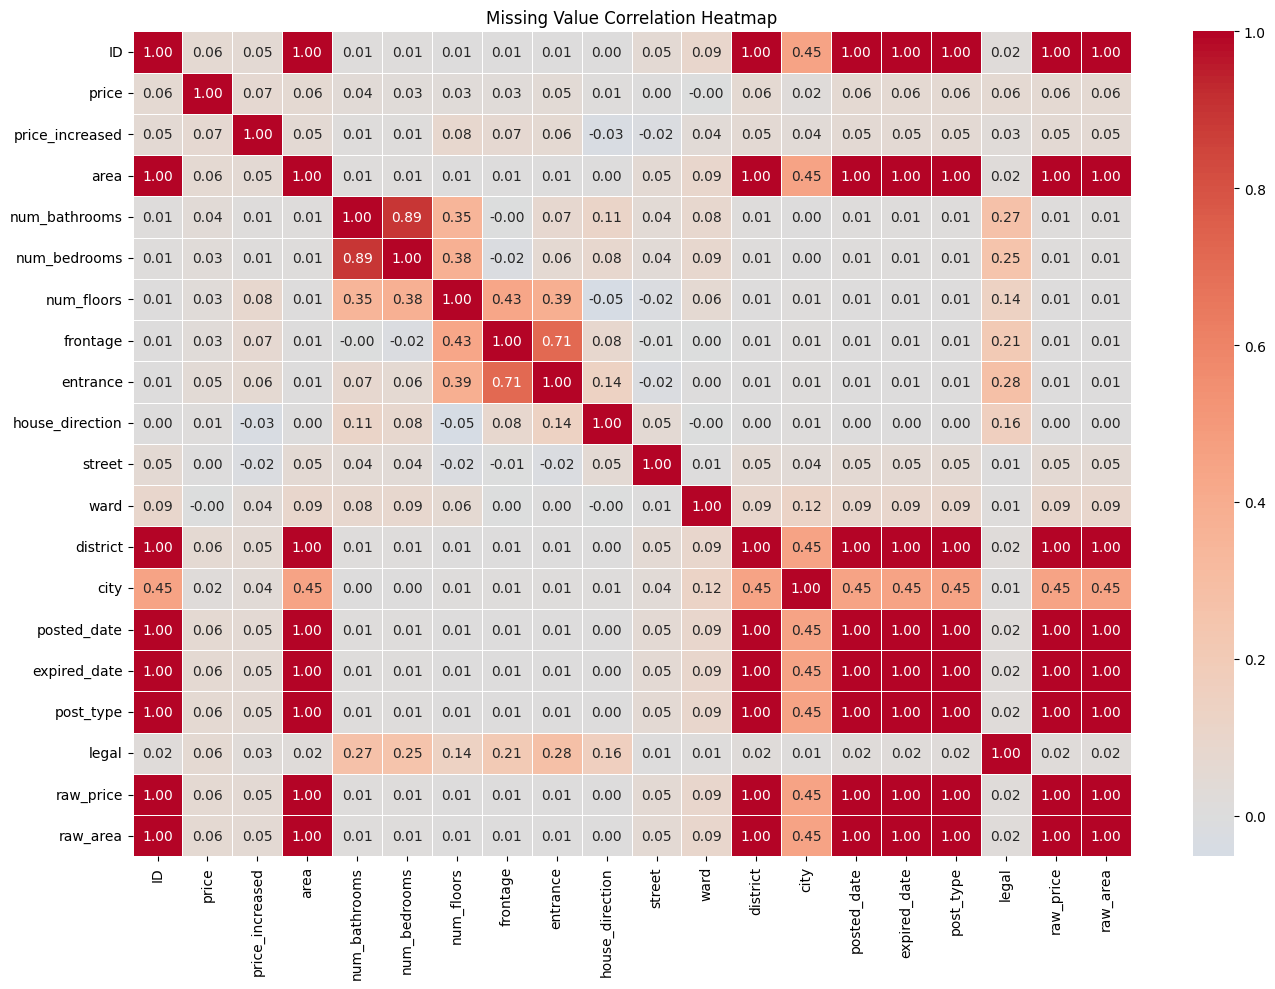

In [1471]:
missing_corr = get_missing_value_correlation_matrix(df)
missing_value_correlation_heatmap(missing_corr)

**Note**: Heatmap có missing cột ID ảnh hưởng 100% đến các cột khác -> xem các dòng có ID là NaN -> drop 

In [1472]:
# Những cột ID có missing values
# df[df['ID'].isnull()]
df.dropna(subset=['ID'], inplace=True)

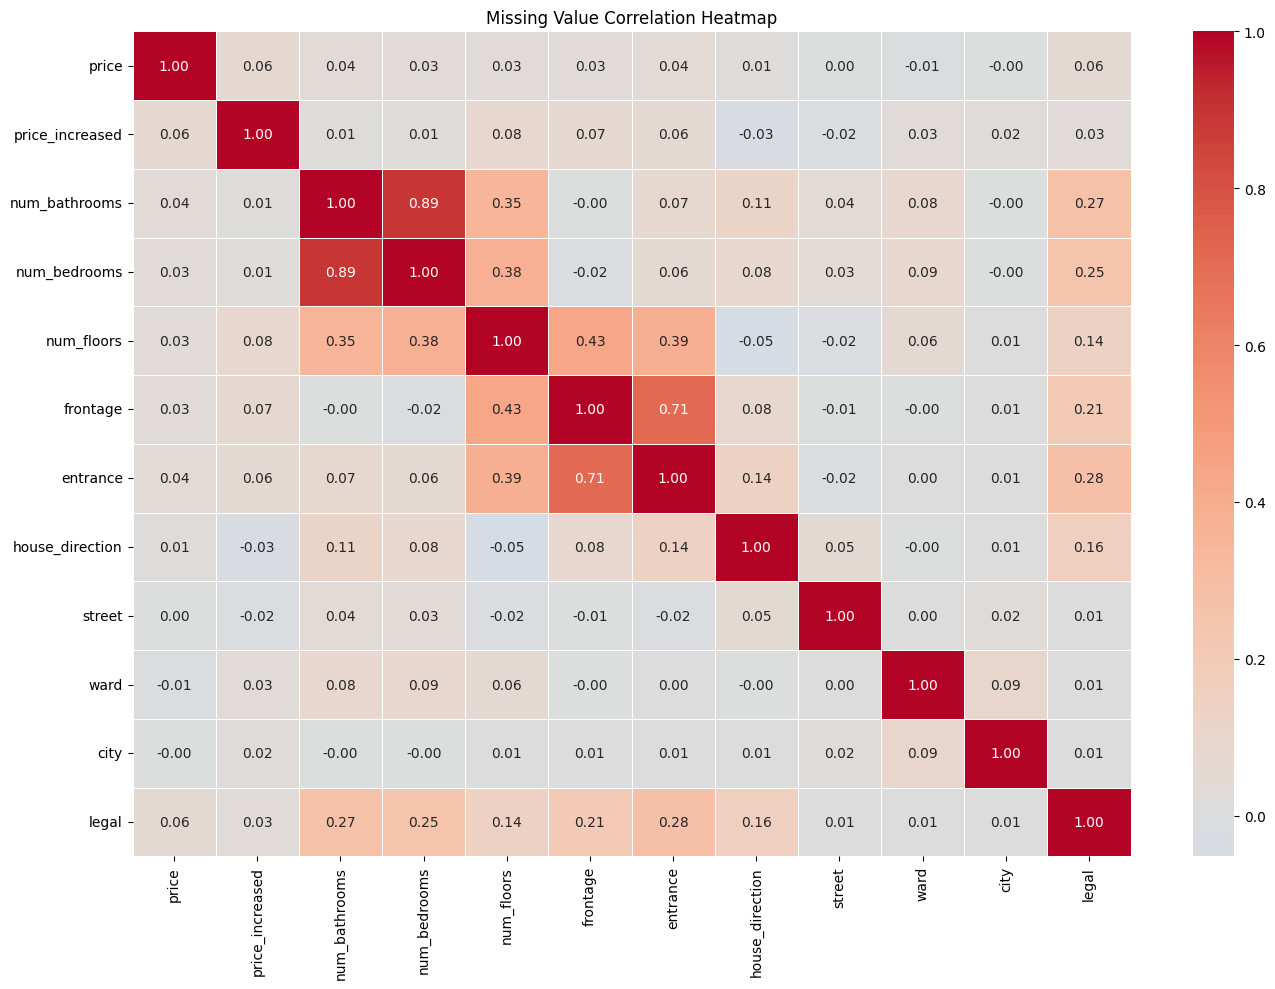

In [1473]:
missing_corr = get_missing_value_correlation_matrix(df)
missing_value_correlation_heatmap(missing_corr)

In [1474]:
df['house_direction'].value_counts()

house_direction
Đông - Nam    680
Tây - Bắc     481
Đông - Bắc    463
Đông          394
Nam           382
Tây - Nam     366
Bắc           321
Tây           260
Name: count, dtype: int64

**Nhận xét chung**: Phân loại theo MCAR (Missing Completely At Random), MAR (Missing At Random), MNAR (Missing Not At Random)

**1. MCAR (Missing Completely At Random)**: price, price_increased, street, ward, city, area, district, raw_price, raw_area

* Quan sát: Lượng dữ liệu thiếu hụt của các cột này cực kỳ thấp (từ 2 đến khoảng hơn 400 dòng). Từ missing correlation heatmap, các biến này gần như không có mối tương quan khuyết thiếu nào với các biến khác (hệ số tương quan đa số xoay quanh 0.00 - 0.07).

* Lý do: Đây có khả năng cao là thiếu do nhập liệu không điền thông tin, lỗi đường truyền, hoặc do người dùng vô tình bỏ sót khi điền form cơ bản.

* Xử lý:

    * Với các cột thiếu vài trăm giá trị (price, street): Sử dụng Median/Mean Imputation (cho biến số như price)
    * Các biến address: street, ward, city, district dùng LLM để điền các giá trị về địa chỉ dựa vào tọa độ longitude và latitude, sau đó điền các missing còn lại bằng KNN imputation


**2. MAR (Missing At Random) / MNAR (Missing Not At Random)**: Có thể chia thành các nhóm có mối liên hệ với nhau.

* Nhóm 1: num_bathrooms và num_bedrooms

    * Quan sát: Từ missing correlation heatmap, cặp biến này có hệ số tương quan missing cực kỳ cao (0.89). Nghĩa là khi một bất động sản không có thông tin phòng ngủ, nó gần như chắc chắn sẽ không có thông tin phòng tắm. Số lượng missing cũng xấp xỉ nhau (4823 và 4267).

    * Lý do: Về mặt nghiệp vụ, giả thiết loại hình bất động sản là "Đất nền", "Đất nông nghiệp" hoặc "Nhà xưởng", việc không có phòng ngủ/phòng tắm là hiển nhiên nên người đăng sẽ bỏ trống. Hoặc do người đăng lười điền thông tin chi tiết cấu trúc nhà.

    * Xử lý: Nếu là đất nền, gán giá trị bằng 0 dựa vào LLM imputation. Nếu là nhà ở/chung cư, có thể dùng KNN Imputation để dự đoán số phòng.

* Nhóm 2: frontage (Mặt tiền) và entrance (Đường vào)

    * Quan sát: Tương quan missing giữa 2 cột này ở mức cao (0.71) và số lượng missing đáng kể (6557 và 7209). 2 biến cũng có tương quan missing khá lớn (tầm trung) với num_floors (0.43 và 0.39).

    * Lý do: Giả thiết nếu bất động sản là Căn hộ chung cư, các thông số này không có ý nghĩa nên bị bỏ trống. Một lý do khác thiên về MNAR là nhà nằm trong hẻm quá sâu/nhỏ, người bán cố tình giấu thông tin entrance để tránh mất giá.

    * Xử lý: 
        * Nếu là đất nền, gán giá trị bằng 0 dựa vào LLM imputation.
        * Đối với nhà đất ở, có thể tạo thêm một hạng mục là "Unknown" (Không xác định).

* Nhóm 3: legal (Pháp lý) và num_floors (Số tầng)

    * Quan sát: 
        * legal có lượng missing khá (2011) và có sự tương quan rải rác với cấu trúc nhà (num_bathrooms 0.27, entrance 0.28). 
        * num_floors (missing 6477) thì tương quan với toàn bộ nhóm cấu trúc nhà (frontage, entrance, bedrooms...).

    * Lý do: Giả thiết bất động sản chưa có sổ đỏ/pháp lý rõ ràng người bán có xu hướng bỏ trống cột legal (MNAR). Với num_floors, tương tự như phòng ngủ, đất nền hoặc căn hộ 1 tầng sẽ thường bị bỏ trống trường này.

    * Xử lý: 
       * Với giá trị Null thì điền "Unknown"

* Nhóm 4: house_direction (Hướng nhà)

    * Quan sát: Lượng missing cao nhất tập dữ liệu (10390 dòng) và tương quan khuyết thiếu với các biến khác rất thấp (chỉ 0.14 với entrance và 0.16 với legal).

    * Lý do: Có thể đặt giả thiết hướng nhà mang tính chất phong thủy, không phải ai cũng quan tâm, nhớ, hoặc biết cách xác định hướng để điền hoặc người bán lo sợ hướng nhà xấu, người bán có thể chủ động bỏ qua hoặc quên điền (vì không cần thiết).

    * Xử lý: Điền missing values bằng một label "Unknown" vì vẫn mang thông tin đủ nhiều khi phân tích về hướng nhà.


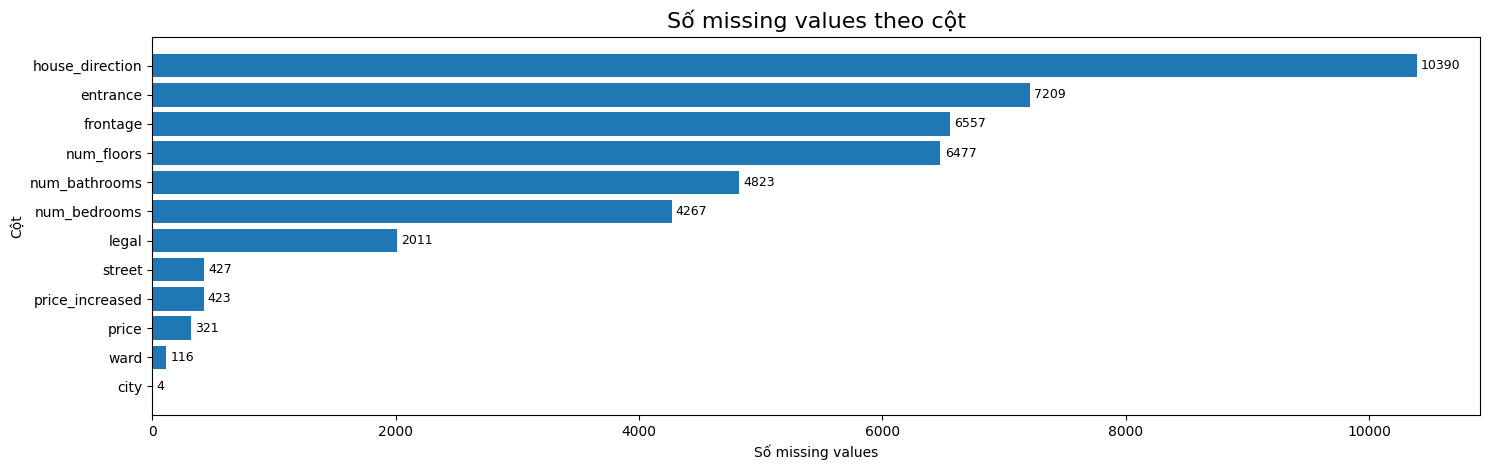

In [1475]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
visualize_missing_values(missing_values)

#### 3.2.3 Data consistency 

In [1476]:
def get_unit(col_name):
    if pd.isna(col_name):
        return None
    

    col_name = str(col_name).strip().replace(',', '') # Chuyển về chuỗi và loại bỏ khoảng trắng thừa
    match = re.search(r"(\d+\.?\d*)", col_name) # Tìm phần số đầu tiên trong chuỗi (ví dụ: '83.1' trong '83.1bhp')
    
    if match:
        unit = col_name[match.end():].strip()
        return unit if unit else "No Unit" # Trả về đơn vị nếu tìm thấy, ngược lại trả về 'No Unit'
    
    return col_name

**1. Xem xét cột raw_price**

In [1477]:
unique_units = df['raw_price'].apply(get_unit).unique()
print(unique_units)

# đếm số lượng unit khác nhau
unit_counts = df['raw_price'].apply(get_unit).value_counts()
print(unit_counts)

['tỷ' 'triệu/m²' 'Thỏa thuận' 'tỷ/m²' 'triệu']
raw_price
tỷ            13032
triệu/m²        355
Thỏa thuận      321
triệu            27
tỷ/m²             2
Name: count, dtype: int64


**Nhận xét:**

* **Quan sát**: Phân phối đơn vị không đồng nhất: Dữ liệu giá đang được biểu diễn dưới 5 hình thức khác nhau, bao gồm giá tổng (tỷ, triệu), giá theo diện tích (triệu/m2, tỷ/m2) và dạng văn bản (Thỏa thuận).
   

* **Xử lý**: Để đồng bộ hóa dữ liệu và phục vụ cho việc phân tích, ta cần quy đổi toàn bộ cột này về chung một đơn vị đo lường duy nhất là Tỷ VNĐ và đưa về dạng số thực (Float). 

    - Đối với đơn vị tỷ: Giữ nguyên giá trị số.
    - Đối với đơn vị triệu: Chia phần số cho 1000 để quy ra Tỷ VNĐ. Cần kiểm tra lại các dòng này xem có phải là tin cho thuê không để quyết định giữ hay xóa.
    - Đối với đơn vị triệu/m2 và tỷ/m2: Kết hợp nhân phần số với giá trị của cột diện tích (area) tương ứng trên cùng một dòng để ra tổng giá. Nếu cột diện tích bị trống (NaN), thì tổng giá cũng được gán thành NaN.
    - Đối với Thỏa thuận: Trực tiếp chuyển thành giá trị khuyết thiếu (NaN) vì không thể suy luận ra con số cụ thể. Sau đó sử dụng các kỹ thuật điền khuyết dựa trên các đặc trưng khác hoặc loại bỏ tùy thuộc vào lượng dữ liệu.

In [1478]:
df['raw_area']

0           56 m²
1          289 m²
2        220,5 m²
3        170,1 m²
4          225 m²
           ...   
13732      110 m²
13733       60 m²
13734       80 m²
13735    1.537 m²
13736      189 m²
Name: raw_area, Length: 13737, dtype: object

**2. Xem xét cột raw_area**

In [1479]:
unique_units = df['raw_area'].apply(get_unit).unique()
print(unique_units)

# đếm số lượng unit khác nhau
unit_counts = df['raw_area'].apply(get_unit).value_counts()
print(unit_counts)

['m²']
raw_area
m²    13737
Name: count, dtype: int64


Nhận xét: raw_area và area không khác nhau về số liệu -> drop cột raw_area

**Xử lý raw_price**

In [1480]:
def convert_raw_price_to_vnd(row):
    """
    Hàm nhận vào 1 dòng (row) của DataFrame.
    Xử lý cột 'raw_price' kết hợp với cột 'area' để quy đổi ra giá trị Tỷ VND
    """
    raw_price_str = row['raw_price']
    area = row['area']
    
    # 1. Bỏ qua nếu giá trị là NaN
    if pd.isna(raw_price_str) or str(raw_price_str).strip() == "":
        return np.nan
    
    # Ép kiểu string và viết thường toàn bộ để dễ so sánh
    s = str(raw_price_str).strip().lower()
    
    # 2. Tách phần SỐ và phần ĐƠN VỊ
    # Regex bắt đoạn đầu chứa số (kèm dấu . hoặc ,) và đoạn sau là chữ
    match = re.search(r"^([\d.,]+)\s*(.*)$", s)
    if not match:
        return np.nan # Nếu là các chữ như "Thỏa thuận", trả về NaN
        
    num_str = match.group(1)
    unit = match.group(2).strip()
    
    # 3. Xử lý phần định dạng số kiểu Việt Nam sang kiểu Python Float
    if "," in num_str and "." in num_str:
        num_str = num_str.replace(".", "").replace(",", ".")
    elif "," in num_str:
        num_str = num_str.replace(",", ".")
        
    try:
        number = float(num_str)
    except ValueError:
        return np.nan
        
    # 4. Tính toán dựa trên ĐƠN VỊ (Mục tiêu: Đưa tất cả về TỶ ĐỒNG)
    if unit in ['tỷ', 'ty', 'billion']:
        return number
    elif unit in ['triệu', 'trieu', 'million']:
        return number / 1000.0
    elif unit in ['nghìn', 'nghin', 'thousand']:
        return number / 1000000.0
    
    # Các đơn vị theo m2 bắt buộc phải có giá trị area hợp lệ (>0)
    elif unit in ['triệu/m²', 'trieu/m2', 'triệu/m2']:
        if pd.notna(area) and area > 0:
            return (number * area) / 1000.0
        else:
            return np.nan # Không có area thì không tính được tổng giá trị
            
    elif unit in ['tỷ/m²', 'ty/m2', 'tỷ/m2']:
        if pd.notna(area) and area > 0:
            return number * area
        else:
            return np.nan
            
    else:
        return np.nan # Các đơn vị không xác định
    
df['price_vnd'] = df.apply(convert_raw_price_to_vnd, axis=1)
df[['raw_price', 'area', 'price_vnd', 'price']].head(10)

,raw_price,area,price_vnd,price
0,"2,7 tỷ",56.0,2.700,2.7000
1,"15,16 tỷ",289.0,15.160,15.1600
2,62 triệu/m²,220.5,13.671,0.0640
3,"15,3 tỷ",170.1,15.300,15.3000
4,"29,5 tỷ",225.0,29.500,29.5000
5,"62,5 triệu/m²",378.0,23.625,0.0645
6,8 tỷ,71.0,8.000,8.0000
7,"78,5 triệu/m²",90.0,7.065,0.0805
8,"2,9 tỷ",157.0,2.900,2.9000
9,"6,2 tỷ",105.0,6.200,6.2000


In [1481]:
#bỏ các cột 'raw_price', 'raw_area', 'price' sau khi đã chuyển đổi xong
df.drop(columns=['raw_price', 'raw_area', 'price'], inplace=True)
df.rename(columns={'price_vnd': 'price'}, inplace=True) #đổi price_vnd thành price
df.head()

,ID,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,house_direction,...,latitude,longitude,has_pink_book,is_verified,posted_date,expired_date,post_type,legal,page_title,price
0,18002827.0,17.9,56.0,1.0,2.0,NaN,1,NaN,NaN,Đông - Nam,...,10.731125,106.610907,1,0,2025-12-18,2026-02-16,Tin thường,Sổ đỏ/ Sổ hồng,"Căn hộ sổ hồng 2PN - 2,7 tỷ thương mại Imperia...",2.700
1,44881455.0,2.1,289.0,NaN,NaN,NaN,0,6.3,5.0,NaN,...,10.780066,106.761850,1,0,2025-12-24,2026-02-22,Tin thường,Sổ đỏ/ Sổ hồng,"Bán đất mặt tiền đường Bình Trưng, 289m², cách...",15.160
2,24453570.0,11.3,220.5,NaN,NaN,NaN,0,10.0,12.0,Nam,...,10.807484,106.798356,1,0,2025-12-26,2026-02-24,Tin thường,Sổ đỏ/ Sổ hồng,Cần bán các lô đất KDC Xuất Nhập Khẩu Tổng Hợp...,13.671
3,37714881.0,32.2,170.1,3.0,3.0,2.0,0,6.3,NaN,Đông,...,10.703543,106.703759,1,0,2025-12-26,2026-02-24,Tin thường,Sổ đỏ/ Sổ hồng,"Giảm giá 1.5ty Bán nhà mt 1030 Lê Văn Lương, 6...",15.300
4,44010390.0,10.4,225.0,36.0,36.0,6.0,1,5.0,NaN,Tây - Nam,...,10.780030,106.616207,1,0,2025-12-27,2026-02-25,Tin thường,Sổ đỏ/ Sổ hồng,Cần bán căn hộ mini tại địa chỉ 20/24 đường Số...,29.500


In [1482]:
df.to_csv(os.path.join(parent_path, 'data', 'processed','2_consistency.csv'), index=False, encoding='utf-8-sig')

**3. Xem xét cột legal**

In [1483]:
df['legal'].unique()

array(['Sổ đỏ/ Sổ hồng', nan, 'Sổ đỏ', 'Hợp đồng mua bán',
       'Sổ đỏ/ Sổ hồng.', 'Sổ hồng riêng', 'Sổ đỏ.', 'Sổ hồng.',
       'Đang chờ sổ', 'Sổ hồng', 'Sổ đỏ/ sổ hồng.', 'SHR',
       'Pháp lý rõ ràng, minh bạch, sang tên công chứng nhanh.', 'Có sổ.',
       'Văn bản thoã thuận', 'HDMB',
       'Pháp lý vững vàng, đang trong quá trình cấp sổ hồng.',
       'Sổ hồng riêng.', 'Sổ hồng/sổ đỏ',
       '+ Pháp lý chuẩn, công chứng ngay.', 'HĐMB + Sổ công ty',
       '- Sổ hoàn công đủ, pháp lý sạch.', 'Mua Bán công chứng vi bằng',
       'Hợp đồng mua bán.', '- Pháp lý: Sổ hồng riêng.', 'Đã có sổ hồng',
       'Có sổ', 'Sổ hồng hoàn công đầy đủ.', 'Shr', 'Đang xây dựng',
       'Sổ Hồng', 'HĐMB', 'Sổ hồng hoàn công.',
       'Pháp lý: Sở hữu lâu dài với khách hàng Việt Nam, 50 năm với khách hàng là người nước ngoài.',
       'Sẵn sàng giao dịch.', 'Pháp lý: Sẵn sàng giao dịch.',
       'Nhà sổ chung, công chứng uỷ quyền giao sổ chính.',
       'Sổ hồng chính chủ.', 'Sổ hồng chung', 'S

Nhận xét: dùng regex để tạo biến

 * Mức 5 (Rất an toàn): Sổ đỏ, Sổ hồng riêng, Đã hoàn công. (Gán nhãn: So_Hong_Rieng)

* Mức 4 (An toàn cao): Hợp đồng mua bán (HĐMB) với chủ đầu tư. (Gán nhãn: Hop_Dong_Mua_Ban)

* Mức 3 (Trung bình): Đang chờ sổ, Đang làm sổ. (Gán nhãn: Cho_So)

* Mức 2 (Rủi ro / Hạn chế quyền): Sổ chung, Đồng sở hữu (SĐC). (Gán nhãn: So_Chung)

* Mức 1 (Rất rủi ro): Vi bằng, Giấy tay, Giấy kê khai đóng thuế, Không pháp lý. (Gán nhãn: Vi_Bang_Giay_Tay)

* Missing (NaN): Có thể quy về nhóm Khong_Ro_Phap_Ly.

In [1484]:
def categorize_legal_regex(text):
    if pd.isna(text) or text == '':
        return 'Unknown'
    
    # Chuyển về chữ thường để dễ so khớp
    text = str(text).lower().strip()
    
    # Mức 1: Rất rủi ro (Vi bằng, giấy tay, không pháp lý, giấy thuế)
    if re.search(r'vi bằng|giấy tay|không pháp lý|hợp đồng thuê|đóng thuế|giấy sử dụng đất', text):
        return 1
        
    # Mức 2: Rủi ro / Hạn chế quyền (Sổ chung, đồng sở hữu)
    elif re.search(r'chung|đồng s|sdc|dsh', text):
        return 2
        
    # Mức 3: Trung bình (Chờ sổ, đang làm sổ)
    elif re.search(r'chờ sổ|đang làm sổ|quá trình cấp sổ|đang xây', text):
        return 3
        
    # Mức 4: An toàn cao (Hợp đồng mua bán, đặt cọc, văn bản thỏa thuận)
    elif re.search(r'hợp đồng|hđmb|hdmb|đặt cọc|văn bản thỏa|văn bản thoã|vbtt|hdt|hddc', text):
        return 4
        
    # Mức 5: Rất an toàn (Sổ đỏ, sổ hồng, sổ riêng, đã có sổ)
    elif re.search(r'sổ hồng|sổ đỏ|shr|sổ riêng|sổ sẵn|có sổ|đã có sổ|sổ hoàn công|sổ công ty|sổ lâu dài|đã có chủ quyền', text):
        return 5
        
    # Các trường hợp chữ chung chung như "pháp lý rõ ràng", "đầy đủ", "công chứng"
    elif re.search(r'pháp lý|công chứng|đầy đủ', text):
         return 5
         
    return 'Unknown'

df['legal_level'] = df['legal'].apply(categorize_legal_regex)

In [1485]:
df.head(10)

,ID,price_increased,area,num_bathrooms,num_bedrooms,num_floors,has_furniture,frontage,entrance,house_direction,...,longitude,has_pink_book,is_verified,posted_date,expired_date,post_type,legal,page_title,price,legal_level
0,18002827.0,17.9,56.0,1.0,2.0,NaN,1,NaN,NaN,Đông - Nam,...,106.610907,1,0,2025-12-18,2026-02-16,Tin thường,Sổ đỏ/ Sổ hồng,"Căn hộ sổ hồng 2PN - 2,7 tỷ thương mại Imperia...",2.700,5
1,44881455.0,2.1,289.0,NaN,NaN,NaN,0,6.3,5.0,NaN,...,106.761850,1,0,2025-12-24,2026-02-22,Tin thường,Sổ đỏ/ Sổ hồng,"Bán đất mặt tiền đường Bình Trưng, 289m², cách...",15.160,5
2,24453570.0,11.3,220.5,NaN,NaN,NaN,0,10.0,12.0,Nam,...,106.798356,1,0,2025-12-26,2026-02-24,Tin thường,Sổ đỏ/ Sổ hồng,Cần bán các lô đất KDC Xuất Nhập Khẩu Tổng Hợp...,13.671,5
3,37714881.0,32.2,170.1,3.0,3.0,2.0,0,6.3,NaN,Đông,...,106.703759,1,0,2025-12-26,2026-02-24,Tin thường,Sổ đỏ/ Sổ hồng,"Giảm giá 1.5ty Bán nhà mt 1030 Lê Văn Lương, 6...",15.300,5
4,44010390.0,10.4,225.0,36.0,36.0,6.0,1,5.0,NaN,Tây - Nam,...,106.616207,1,0,2025-12-27,2026-02-25,Tin thường,Sổ đỏ/ Sổ hồng,Cần bán căn hộ mini tại địa chỉ 20/24 đường Số...,29.500,5
5,40155171.0,22.8,378.0,NaN,NaN,NaN,0,18.0,12.0,Đông - Bắc,...,106.786446,1,0,2025-12-27,2026-02-25,Tin thường,Sổ đỏ/ Sổ hồng,Chính chủ gửi bán 2 lô đất biệt thự dự án Bách...,23.625,5
6,44903942.0,23.1,71.0,2.0,2.0,NaN,1,NaN,NaN,NaN,...,106.691031,0,0,2025-12-27,2026-02-25,Tin thường,NaN,Phòng kinh doanh De La Sol: Cập nhật 9 căn hộ ...,8.000,Unknown
7,14712034.0,8.6,90.0,NaN,NaN,NaN,0,6.0,12.0,Tây - Bắc,...,106.797485,1,0,2025-12-28,2026-02-26,Tin thường,Sổ đỏ,"Bán gấp lô E, dự án đất nền sổ đỏ dự án Sở Văn...",7.065,5
8,42172316.0,25.0,157.0,NaN,NaN,NaN,0,5.0,8.0,Nam,...,106.550853,1,0,2025-12-29,2026-02-27,Tin thường,Sổ đỏ/ Sổ hồng,"Chính chủ cần bán đất xã Tân Phú Trung, Củ Chi...",2.900,5
9,42254345.0,29.8,105.0,2.0,3.0,NaN,0,NaN,NaN,Đông - Nam,...,106.719468,0,0,2025-12-29,2026-02-27,Tin thường,Hợp đồng mua bán,Chủ đầu tư Vietcomreal bán căn hộ 2 VÀ 3 phòng...,6.200,4


#### **3.2.4 Handling missing values**

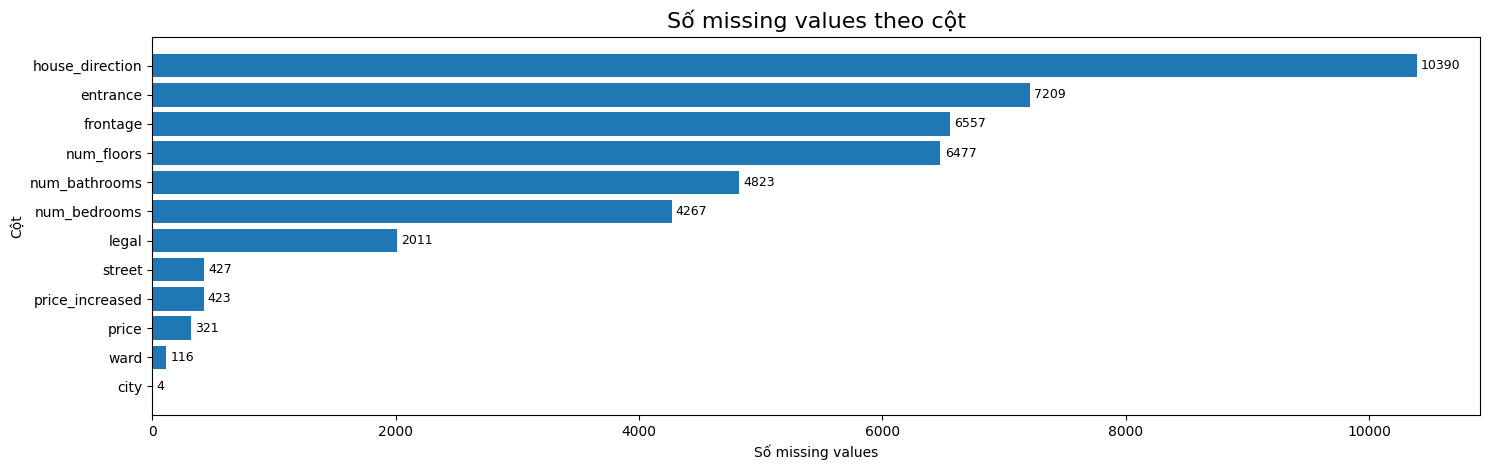

In [1487]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
visualize_missing_values(missing_values)

**a. Nhóm MCAR**: price_increased, area, price, street, ward, district, city

Imputation:
- Median imputaion (numerous data): `price_increased`, `area`
- Dùng LLM để suy từ title ra `price` và sau đó dùng median imputation để điền các missing còn lại
- LLM Geocoding API -> điền missing của cột `street`, `ward`, `district`, `city`

**1. Dùng model Groq - llama-3.3-70b-versatile đề dựa vào title để suy ra price**

In [ ]:
from groq import Groq


client = Groq(api_key=GROQ_API_KEY)

In [1489]:
df = pd.read_csv(os.path.join(parent_path, 'data', 'processed','2_consistency.csv'))
missing_price_indices = df[df['price'].isnull()].head(30).index

print(f"Tìm thấy {len(missing_price_indices)} dòng bị thiếu price để test.")

def extract_price_from_title(area, title):
    prompt = f"""Bạn là một chuyên gia trích xuất dữ liệu bất động sản.
    Nhiệm vụ: Trích xuất mức giá bán từ tiêu đề sau và quy đổi tất cả về đơn vị Tỷ VNĐ.
    Yêu cầu bắt buộc: 
    - Chỉ trả về ĐÚNG MỘT CON SỐ thập phân (ví dụ: 2.7, 15.5, 0.95). 
    - Nếu đơn vị là Triệu, hãy chia cho 1000 để ra Tỷ (VD: 900 triệu -> 0.9).
    - Nếu đơn vị là triệu/m2, hãy nhân với diện tích để ra tổng giá rồi chia cho 1000 (VD: 20 triệu/m2 * 100m2 -> 2 tỷ -> trả về 2.0).
    - Nếu đơn vị là tỷ/m2, hãy nhân với diện tích để ra tổng giá (VD: 0.05 tỷ/m2 * 100m2 -> 5 tỷ -> trả về 5.0).
    - Không kèm thêm bất kỳ chữ, ký tự hay lời giải thích nào.
    - Nếu không có thông tin giá, hãy trả về chữ 'None'.

    Diện tích: {area}
    Tiêu đề: "{title}"
    """
    try:
        chat_completion = client.chat.completions.create(
            messages=[
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            model="llama-3.3-70b-versatile", 
            temperature=0,
            # max_tokens=10,
        )
        return chat_completion.choices[0].message.content.strip()
    except Exception as e:
        return f"Error: {e}"

# 3. Tiến hành điền khuyết và Ghi log
logs = []

for idx in missing_price_indices:
    page_title = df.loc[idx, 'page_title']
    area = df.loc[idx, 'area']
    
    # Bỏ qua nếu page_title cũng bị trống
    if pd.isna(page_title):
        continue

    llm_response = extract_price_from_title(area, page_title)

    extracted_price = None
    try:
        # Lọc lấy số phòng hờ LLM vẫn trả về chữ
        numbers = re.findall(r"[-+]?\d*\.\d+|\d+", llm_response)
        if numbers:
            extracted_price = float(numbers[0])
            # Cập nhật vào DataFrame
            df.loc[idx, 'price'] = extracted_price
    except:
        pass
        
    # Ghi log
    logs.append({
        'Index': idx,
        'page_title': page_title,
        'LLM_Raw_Output': llm_response,
        'Parsed_Price': extracted_price
    })
    
    print(f"Đã xử lý dòng {idx}")

log_df = pd.DataFrame(logs)
print(log_df.to_string())

# Lưu file log ra CSV để tiện theo dõi
log_df.to_csv('llm_price_imputation_log.csv', index=False, encoding='utf-8-sig')

Tìm thấy 30 dòng bị thiếu price để test.
Đã xử lý dòng 29
Đã xử lý dòng 34
Đã xử lý dòng 60
Đã xử lý dòng 83
Đã xử lý dòng 115
Đã xử lý dòng 127
Đã xử lý dòng 141
Đã xử lý dòng 145
Đã xử lý dòng 146
Đã xử lý dòng 157
Đã xử lý dòng 184
Đã xử lý dòng 210
Đã xử lý dòng 285
Đã xử lý dòng 412
Đã xử lý dòng 433
Đã xử lý dòng 439
Đã xử lý dòng 460
Đã xử lý dòng 526
Đã xử lý dòng 530
Đã xử lý dòng 650
Đã xử lý dòng 671
Đã xử lý dòng 706
Đã xử lý dòng 740
Đã xử lý dòng 799
Đã xử lý dòng 864
Đã xử lý dòng 867
Đã xử lý dòng 937
Đã xử lý dòng 951
Đã xử lý dòng 959
Đã xử lý dòng 1065
    Index                                                                                            page_title LLM_Raw_Output  Parsed_Price
0      29                Bán đất tại Nguyễn Văn Tạo, 360m2, giá thỏa thuận, mặt tiền 15m, view đẹp, Nhà Bè, HCM           None           NaN
1      34                              Cập nhật mới nhất giỏ hàng các căn Regency giá tốt. Hotline 0907 004 ***           None           NaN

**2. Dùng median imputation để điền các missing values còn lại của "price_increased", "area", "price"**

In [1490]:
median_cols = ["price_increased", "area", "price"]

for c in median_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")   # phòng khi đang là object
        med = df[c].median()
        print(f"Giá trị trung vị {med} - cột '{c}'")
        df[c] = df[c].fillna(med)

Giá trị trung vị 13.1 - cột 'price_increased'
Giá trị trung vị 80.0 - cột 'area'
Giá trị trung vị 8.2 - cột 'price'


**b. Nhóm MAR, MNAR**

**1. Dùng LLM và API của geolocator để lấy địa chỉ từ longitude và latitude để sửa cột không đúng và điền missing values**

In [ ]:
df[df['street'].isnull() | df['ward'].isnull()][['page_title', 'street', 'ward', 'district', 'latitude', 'longitude']].head(20)

,page_title,street,ward,district,latitude,longitude
20,Bán nhà hẻm thông Song Hành gần Nguyễn Văn Quá,NaN,Phường Tân Hưng Thuận,Quận 12,10.839325,106.624313
99,NHÀ CẤP 4 2 MẶT TIỀN TRƯỚC SAU KHU BÀN CỜ NGAY...,NaN,Phường Tăng Nhơn Phú A,Quận 9,10.847128,106.795657
128,Bán đất MT TL373 gần đường Xuyên Á và KCN Tây Bắc,Xã Tân An Hội,NaN,Xã Tân An Hội,10.973703,106.484253
191,"Bán nhà riêng tại KC76.Tân Thuận Tây, Q7, TP. ...",NaN,KC76.Phường Tân Thuận Tây,Quận 7,10.751398,106.722077
204,Bán nhà mặt tiền Đường Số Phường Tân Quy Quận ...,NaN,Phường Tân Quy,Quận 7,10.742468,106.710397
209,"Bán đất 672m2 tại Long Thạnh Mỹ, Quận 9, HCM, ...",NaN,Phường Long Thạnh Mỹ,Quận 9,10.838086,106.820345
232,Mặt tiền tiền kinh doanh trần văn kiểu quận 6 ...,NaN,Phường 10,Quận 6,10.737343,106.628184
263,NHÀ 3 TẦNG - HẺM XE TẢI - 148M2 - NGANG 5X30 -...,NaN,Phường Linh Xuân,Phường Linh Xuân,10.882575,106.772641
303,"Bán nhà mới xây đã hoàn công, hẻm xe hơi, nở h...",NaN,Phường Tân Chánh Hiệp,Quận 12,10.863782,106.625227
332,"NHÀ 2 TẦNG, ÂU DƯƠNG LÂN Q8, HẺM 5M, NGANG 4,3...",NaN,Phường 2,Quận 8,10.747014,106.686521


In [ ]:
from geopy.geocoders import Nominatim

geolocator = Nominatim(user_agent="my_app")
lat, lon = 10.784249, 106.759498
location = geolocator.reverse(f"{lat}, {lon}")
print(location.address)

Đường số 6, Khu phố 32, Phường Bình Trưng, Thủ Đức, Thành phố Hồ Chí Minh, 08408, Việt Nam


In [1493]:
!pip install geopy

In [ ]:
import json
import requests
from pdb import main
import time
from geopy.geocoders import Nominatim


client = Groq(api_key=GROQ_API_KEY)
geolocator = Nominatim(user_agent="MyFriend")
TEST_LIMIT = 20 

In [1498]:
TEST_LIMIT = 20 

def parse_and_fix_address_with_llm(raw_address, current_data):
    """Sử dụng LLM để Điền Khuyết và Sửa Lỗi dữ liệu địa lý."""
    prompt = f"""Bạn là một chuyên gia dữ liệu địa lý và hành chính Việt Nam.
Tôi có một địa chỉ thô được lấy từ tọa độ bản đồ: "{raw_address}"

Và đây là dữ liệu HIỆN TẠI trong cơ sở dữ liệu (có thể bị thiếu hoặc điền sai cột):
- street: {current_data.get('street')}
- ward: {current_data.get('ward')}
- district: {current_data.get('district')}
- city: {current_data.get('city')}

NHIỆM VỤ:
1. Đối chiếu địa chỉ thô với dữ liệu hiện tại.
2. Nếu dữ liệu hiện tại bị thiếu (null/None/nan), hãy điền vào dựa trên địa chỉ thô.
3. Nếu dữ liệu hiện tại BỊ SAI CẤP HÀNH CHÍNH (Ví dụ: cột district lại chứa tên Xã/Phường, hoặc ngược lại), hãy sửa lại cho đúng chuẩn.
4. Trả về 4 trường thông tin đã được chuẩn hóa và sửa lỗi.

BẮT BUỘC:
- Chỉ trả về duy nhất một chuỗi JSON hợp lệ.
- Không dùng markdown block (không có ```json).
- Không giải thích gì thêm.
- Nếu thông tin nào thực sự không tồn tại, để giá trị null.

Ví dụ Output:
{{"street": "Đường Lê Lợi", "ward": "Phường Bến Nghé", "district": "Quận 1", "city": "Hồ Chí Minh"}}
"""
    try:
        chat_completion = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile", 
            temperature=0, 
            max_tokens=200,
        )
        response_text = chat_completion.choices[0].message.content.strip()
        
        # Tiền xử lý để đảm bảo JSON hợp lệ
        response_text = re.sub(r"^```json\s*", "", response_text)
        response_text = re.sub(r"\s*```$", "", response_text)
        
        return json.loads(response_text)
    except Exception as e:
        print(f"Lỗi bóc tách LLM: {e}")
        return None

cols_to_fill = ['street', 'ward', 'district', 'city']

mask_nan = df[cols_to_fill].isnull().any(axis=1)

mask_wrong_district = df['district'].str.contains(r'(?i)^(xã|phường|thị trấn)\b', na=False)
mask_wrong_ward = df['ward'].str.contains(r'(?i)^(quận|huyện|thành phố)\b', na=False)

mask_to_process = mask_nan | mask_wrong_district | mask_wrong_ward
missing_indices = df[mask_to_process].index

if TEST_LIMIT:
    missing_indices = missing_indices[:TEST_LIMIT]
    print(f"Đang xử lý {TEST_LIMIT} dòng đầu tiên bị thiếu hoặc có nghi ngờ sai dữ liệu.")
else:
    print(f"Tìm thấy {len(missing_indices)} dòng cần điền khuyết hoặc sửa lỗi.")

logs = []
for idx in missing_indices:
    lat = df.loc[idx, 'latitude']
    lon = df.loc[idx, 'longitude']
    
    if pd.isna(lat) or pd.isna(lon):
        continue
        
    print(f"\n--- Xử lý dòng {idx} | Tọa độ: {lat}, {lon} ---")
    
    # Lấy dữ liệu hiện tại của dòng
    current_row_data = {
        col: str(df.loc[idx, col]) if pd.notna(df.loc[idx, col]) else None 
        for col in cols_to_fill
    }
    print(f"Dữ liệu cũ: {current_row_data}")
    
    # Lấy địa chỉ thô từ tọa độ
    try:
        location = geolocator.reverse((lat, lon), exactly_one=True, timeout=10)
        raw_address = location.address if location else None
    except Exception as e:
        print(f"Lỗi Geopy (Bản đồ): {e}")
        raw_address = None
        
    if raw_address:
        # Gửi CẢ địa chỉ thô và dữ liệu cũ cho LLM để phân tích & sửa lỗi
        parsed_data = parse_and_fix_address_with_llm(raw_address, current_row_data)
        
        if parsed_data:
            print(f" > LLM trả về : {parsed_data}")
            
            log_entry = {
                'Index': idx,
                'Raw_Address_Map': raw_address
            }
            
            is_changed = False
            
            # Cập nhật vào DataFrame và Ghi log chi tiết
            for col in cols_to_fill:
                old_val = current_row_data[col]
                new_val = parsed_data.get(col)
                
                # Chuyển về string để so sánh, bỏ qua khoảng trắng thừa
                old_compare = str(old_val).strip().lower() if old_val else ""
                new_compare = str(new_val).strip().lower() if new_val else ""
                
                # Ghi nhận log CŨ -> MỚI
                log_entry[f'{col}_Old'] = old_val
                log_entry[f'{col}_New'] = new_val
                
                # Nếu LLM phát hiện sự khác biệt (có dữ liệu mới hoặc sửa dữ liệu sai)
                if new_val and old_compare != new_compare:
                    df.loc[idx, col] = new_val
                    is_changed = True
                    log_entry[f'{col}_Action'] = "Điền mới" if not old_val else "Sửa lỗi"
                else:
                    log_entry[f'{col}_Action'] = "Giữ nguyên"
            
            if is_changed:
                print(" > Đã cập nhật dữ liệu mới/sửa lỗi vào DataFrame.")
            else:
                print(" > Dữ liệu cũ đã chuẩn, không cần sửa.")
                
            logs.append(log_entry)
    else:
        print("  > Không tìm thấy địa chỉ thô trên bản đồ.")
        
    time.sleep(1.5) 

# Lưu file Log
if logs:
    log_df = pd.DataFrame(logs)
    # Sắp xếp lại cột cho dễ nhìn: Tên cột Old - New - Action nằm cạnh nhau
    col_order = ['Index', 'Raw_Address_Map']
    for col in cols_to_fill:
        col_order.extend([f'{col}_Old', f'{col}_New', f'{col}_Action'])
    
    log_df = log_df[col_order]
    
    log_file = 'llm_geo_fix_and_impute_log.csv'
    log_df.to_csv(log_file, index=False, encoding='utf-8-sig')
    print(f"Đã lưu lịch sử thay đổi vào: {log_file}")
else:
    print("Không có dòng nào được thay đổi thành công.")

C:\Users\Mario\AppData\Local\Temp\ipykernel_47824\4229406038.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_wrong_district = df['district'].str.contains(r'(?i)^(xã|phường|thị trấn)\b', na=False)
C:\Users\Mario\AppData\Local\Temp\ipykernel_47824\4229406038.py:52: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  mask_wrong_ward = df['ward'].str.contains(r'(?i)^(quận|huyện|thành phố)\b', na=False)


Đang xử lý 20 dòng đầu tiên bị thiếu hoặc có nghi ngờ sai dữ liệu.

--- Xử lý dòng 87 | Tọa độ: 10.786529634137, 106.628189624788 ---
Dữ liệu cũ: {'street': 'Tân Phú', 'ward': 'Phường Phú Thọ Hòa', 'district': 'Phường Phú Thọ Hòa', 'city': 'Hồ Chí Minh'}
 > LLM trả về : {'street': 'Hẻm 249 Vườn Lài', 'ward': 'Phường Phú Thọ Hòa', 'district': 'Quận Tân Phú', 'city': 'Thành phố Hồ Chí Minh'}
 > Đã cập nhật dữ liệu mới/sửa lỗi vào DataFrame.

--- Xử lý dòng 128 | Tọa độ: 10.9737032467648, 106.484252991417 ---
Dữ liệu cũ: {'street': 'Xã Tân An Hội', 'ward': 'Xã Tân An Hội', 'district': 'Xã Tân An Hội', 'city': 'Hồ Chí Minh'}
 > LLM trả về : {'street': None, 'ward': None, 'district': 'Huyện Bình Chánh', 'city': 'Thành phố Hồ Chí Minh'}
 > Đã cập nhật dữ liệu mới/sửa lỗi vào DataFrame.

--- Xử lý dòng 174 | Tọa độ: 10.8157424349268, 106.719498671307 ---
Dữ liệu cũ: {'street': 'Bình Thạnh', 'ward': 'Phường 27', 'district': 'Phường 27', 'city': 'Hồ Chí Minh'}
 > LLM trả về : {'street': 'Hẻm 82

**2. Xử lý cột num_bathrooms, num_bedrooms, frontage và entrance: Điền giá trị bằng 0 dựa vào LLM imputation phân tích từ cột `title` nếu là đất nền và nếu là đất ở thì điền "Unknown"**

In [1496]:
TEST_LIMIT = 20

def classify_property_from_title(title):
    """Sử dụng LLM để phân tích tiêu đề và trả về loại hình BĐS."""
    prompt = f"""Bạn là một chuyên gia phân tích dữ liệu bất động sản.
Nhiệm vụ: Đọc tiêu đề bài đăng sau và phân loại xem nó thuộc loại hình nào.
Tiêu đề: "{title}"

Có 3 phân loại:
1. "đất nền": Bao gồm bán đất trống, đất nền dự án, đất thổ cư (chưa có nhà trên đất).
2. "đất ở": Bao gồm bán nhà, bán căn hộ, biệt thự, nhà phố (đã có công trình nhà ở).
3. "khác": Không rõ ràng hoặc thuộc loại hình khác (kho xưởng, cho thuê...).

BẮT BUỘC: 
- Trả về đúng 1 chuỗi JSON với key là "type" và value là 1 trong 3 phân loại trên.
- Không dùng markdown block. Không giải thích thêm.
Ví dụ 1: {{"type": "đất nền"}}
Ví dụ 2: {{"type": "đất ở"}}
"""
    try:
        chat_completion = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="llama-3.3-70b-versatile",
            temperature=0, 
            max_tokens=50,
        )
        response_text = chat_completion.choices[0].message.content.strip()
        
        # Làm sạch chuỗi trả về để đảm bảo parse JSON thành công
        response_text = re.sub(r"^```json\s*", "", response_text)
        response_text = re.sub(r"\s*```$", "", response_text)
        
        return json.loads(response_text)
    except Exception as e:
        print(f"Lỗi LLM: {e}")
        return None

In [ ]:
cols_to_fill = ['num_bathrooms', 'num_bedrooms', 'frontage', 'entrance']

# Ép kiểu các cột này sang dạng 'object' để Pandas cho phép điền chữ "Unknown" vào chung với số
for col in cols_to_fill:
    df[col] = df[col].astype(object)

# Lọc các dòng: Có ít nhất 1 cột trong cols_to_fill bị thiếu VÀ cột page_title phải có dữ liệu
mask_nan = df[cols_to_fill].isnull().any(axis=1)
mask_has_title = df['page_title'].notnull()

missing_indices = df[mask_nan & mask_has_title].index

if TEST_LIMIT:
    missing_indices = missing_indices[:TEST_LIMIT]
    print(f"Đang xử lý {TEST_LIMIT} dòng đầu tiên.")
else:
    print(f"Tìm thấy {len(missing_indices)} dòng cần xử lý.")

logs = []

for idx in missing_indices:
    title = df.loc[idx, 'page_title']
    print(f"\nXử lý dòng: {idx}")
    print(f"Tiêu đề: {title}")
    
    # Gọi LLM để phân loại
    llm_result = classify_property_from_title(title)
    
    if llm_result and 'type' in llm_result:
        prop_type = llm_result['type']
        print(f"Phân loại LLM: {prop_type}")
        
        # Quyết định giá trị cần điền
        fill_value = None
        if prop_type == "đất nền":
            fill_value = 0
        elif prop_type == "đất ở":
            fill_value = "Unknown"
        
        # Ghi Log và Cập nhật DataFrame
        log_entry = {
            'Index': idx,
            'page_title': title,
            'LLM_Type': prop_type,
            'Value_Filled': fill_value
        }
        
        if fill_value is not None:
            for col in cols_to_fill:
                # Chỉ điền nếu ô hiện tại đang là NaN
                if pd.isna(df.loc[idx, col]):
                    log_entry[f'{col}_Old'] = "NaN"
                    df.loc[idx, col] = fill_value
                    log_entry[f'{col}_New'] = fill_value
                else:
                    log_entry[f'{col}_Old'] = df.loc[idx, col]
                    log_entry[f'{col}_New'] = df.loc[idx, col]
            print(f"Đã điền giá trị: {fill_value}")
        else:
            print("Loại hình 'khác', bỏ qua không điền.")
            
        logs.append(log_entry)
        
    # Tránh gửi quá nhanh làm tắc nghẽn API
    time.sleep(0.5)

# output_file = '2_consistency_features_imputed.csv'
# df.to_csv(output_file, index=False, encoding='utf-8-sig')

if logs:
    log_df = pd.DataFrame(logs)
    log_file = 'llm_features_imputation_log.csv'
    log_df.to_csv(log_file, index=False, encoding='utf-8-sig')
    print(f"Đã lưu lịch sử thay đổi vào: {log_file}")
else:
    print("Không có dữ liệu nào được cập nhật.")

Đang xử lý 20 dòng đầu tiên.

--- Xử lý dòng 0 ---
Tiêu đề: Căn hộ sổ hồng 2PN - 2,7 tỷ thương mại Imperial Place. LH: 0963 129 *** Mr Đạt
Phân loại LLM: đất ở
 > Đã điền giá trị: Unknown

--- Xử lý dòng 1 ---
Tiêu đề: Bán đất mặt tiền đường Bình Trưng, 289m², cách Nguyễn Thị Định 300m, giá ~52tr/m2
Phân loại LLM: đất nền
 > Đã điền giá trị: 0

--- Xử lý dòng 2 ---
Tiêu đề: Cần bán các lô đất KDC Xuất Nhập Khẩu Tổng Hợp II, Phú Hữu, Quận 9, đối diện Park Riverside
Phân loại LLM: đất nền
 > Đã điền giá trị: 0

--- Xử lý dòng 3 ---
Tiêu đề: Giảm giá 1.5ty Bán nhà mt 1030 Lê Văn Lương, 6.3m x 27m. Đang cho thuê 40tr/tháng, còn HĐ 5 năm
Phân loại LLM: đất ở
 > Đã điền giá trị: Unknown

--- Xử lý dòng 4 ---
Tiêu đề: Cần bán căn hộ mini tại địa chỉ 20/24 đường Số 1, phường Bình Hưng Hoà A, Bình Tân
Phân loại LLM: đất ở
 > Đã điền giá trị: Unknown

--- Xử lý dòng 5 ---
Tiêu đề: Chính chủ gửi bán 2 lô đất biệt thự dự án Bách Khoa, P. Phú Hữu, Tp Thủ Đức, DT 12x34m, DT 18x21m
Phân loại LLM: đất

**3. Xử lý cột house_direction: điền Unknown cho cột null**

In [1499]:
# Xử lý cột house_direction: điền Unknown cho cột null
df['house_direction'] = df['house_direction'].fillna('Unknown')